### Load the panel

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet
from alpha_research.validation import (
    calculate_daily_ic,
    calculate_long_short_spread,
    calculate_quantile_returns,
    summarise_ic,
)

factor_panel = load_parquet(
    PROCESSED_DATA_DIR / "factor_panel.parquet"
)

### Test factors

In [2]:
rank_ic = calculate_daily_ic(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    method="spearman",
    min_observations=30,
)

summarise_ic(rank_ic)

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
0,2634,0.019718,0.277559,0.071042,3.646044,0.555809


In [3]:
pearson_ic = calculate_daily_ic(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    method="pearson",
    min_observations=30,
)

summarise_ic(pearson_ic)

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
0,2634,0.031045,0.286453,0.108376,5.562122,0.558846


Text(0, 0.5, 'Rank IC')

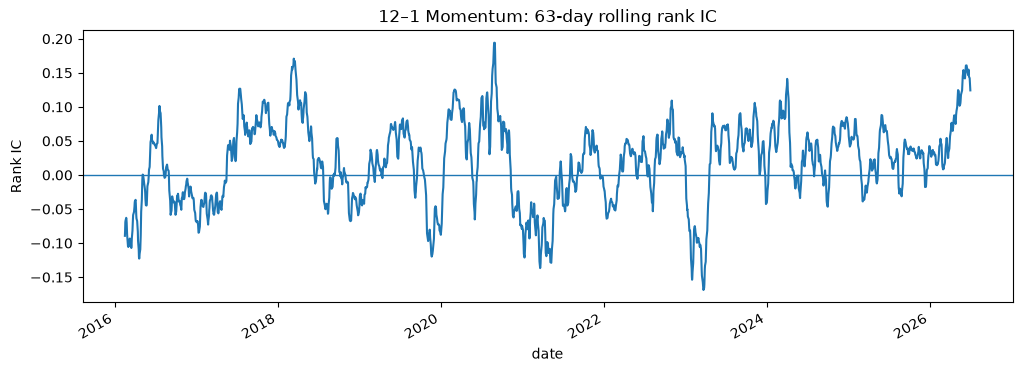

In [4]:
rank_ic["rolling_ic_63"] = (
    rank_ic["ic"]
    .rolling(63, min_periods=30)
    .mean()
)

ax = rank_ic.plot(
    x="date",
    y="rolling_ic_63",
    figsize=(12, 4),
    title="12–1 Momentum: 63-day rolling rank IC",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Rank IC")

### Quantile return analysis

In [5]:
quantile_returns = calculate_quantile_returns(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    quantiles=5,
    min_observations=30,
)

quantile_returns.head(10)

,date,quantile,mean_forward_return,observations
0,2016-01-04,1,-0.058507,20
1,2016-01-04,2,-0.044239,19
2,2016-01-04,3,-0.039653,19
3,2016-01-04,4,-0.043141,19
4,2016-01-04,5,-0.030609,20
5,2016-01-05,1,-0.053508,20
6,2016-01-05,2,-0.036827,19
7,2016-01-05,3,-0.031883,19
8,2016-01-05,4,-0.039217,19
9,2016-01-05,5,-0.023184,20


In [6]:
average_quantile_returns = (
    quantile_returns.groupby("quantile")["mean_forward_return"]
    .mean()
)

average_quantile_returns

quantile
1    0.003978
2    0.003281
3    0.003234
4    0.003226
5    0.005296
Name: mean_forward_return, dtype: float64

<Axes: title={'center': 'Average 5-day forward return by momentum quintile'}, xlabel='quantile'>

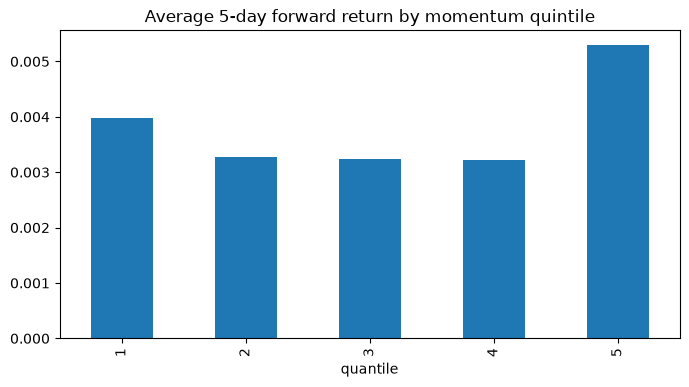

In [7]:
average_quantile_returns.plot(
    kind="bar",
    figsize=(8, 4),
    title="Average 5-day forward return by momentum quintile",
)

In [8]:
long_short = calculate_long_short_spread(
    quantile_returns,
    top_quantile=5,
    bottom_quantile=1,
)

long_short["cumulative_return"] = (
    1.0 + long_short["long_short_return"]
).cumprod()

long_short.tail()

,date,long_short_return,cumulative_return
2629,2026-06-18,-0.040778,11.222514
2630,2026-06-22,-0.044244,10.725984
2631,2026-06-23,0.027195,11.017676
2632,2026-06-24,-0.023534,10.758382
2633,2026-06-25,-0.111337,9.560576


### Run all four factors

In [9]:
factor_columns = {
    "12-1 Momentum": "mom_12_1m_z",
    "3-Month Momentum": "mom_3m_z",
    "1-Month Reversal": "reversal_1m_z",
    "Realised Volatility": "realised_vol_63_z",
}

summary_rows = []

for factor_name, factor_column in factor_columns.items():
    ic = calculate_daily_ic(
        factor_panel,
        factor_column=factor_column,
        forward_return_column="forward_ret_5d",
        method="spearman",
        min_observations=30,
    )

    summary = summarise_ic(ic).iloc[0].to_dict()
    summary["factor"] = factor_name
    summary_rows.append(summary)

ic_summary = pd.DataFrame(summary_rows).set_index("factor")
ic_summary

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
factor,,,,,,
12-1 Momentum,2634.0,0.019718,0.277559,0.071042,3.646044,0.555809
3-Month Momentum,2823.0,0.002779,0.243563,0.011411,0.606264,0.529933
1-Month Reversal,2865.0,0.005303,0.222045,0.023882,1.278315,0.490750
Realised Volatility,2823.0,0.025340,0.292340,0.086680,4.605470,0.544102


## Factor robustness and stability

### Horizon comparison

In [10]:
from alpha_research.validation import (
    calculate_ic_by_horizon,
    calculate_non_overlapping_ic,
    calculate_rolling_ic,
    calculate_subperiod_ic,
)

In [11]:
factor_columns = {
    "12-1 Momentum": "mom_12_1m_z",
    "3-Month Momentum": "mom_3m_z",
    "1-Month Reversal": "reversal_1m_z",
    "Realised Volatility": "realised_vol_63_z",
}

horizon_results = []

for factor_name, factor_column in factor_columns.items():
    result = calculate_ic_by_horizon(
        factor_panel,
        factor_column=factor_column,
        forward_return_columns=[
            "forward_ret_1d",
            "forward_ret_5d",
        ],
        method="spearman",
        min_observations=30,
    )

    result["factor"] = factor_name
    horizon_results.append(result)

horizon_summary = pd.concat(
    horizon_results,
    ignore_index=True,
)

horizon_summary[
    [
        "factor",
        "forward_return_column",
        "mean_ic",
        "std_ic",
        "ic_ir",
        "t_stat",
        "positive_fraction",
    ]
]

,factor,forward_return_column,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
0,12-1 Momentum,forward_ret_1d,0.019428,0.283058,0.068636,3.525242,0.541698
1,12-1 Momentum,forward_ret_5d,0.019718,0.277559,0.071042,3.646044,0.555809
2,3-Month Momentum,forward_ret_1d,0.003719,0.249408,0.014913,0.792924,0.519278
3,3-Month Momentum,forward_ret_5d,0.002779,0.243563,0.011411,0.606264,0.529933
4,1-Month Reversal,forward_ret_1d,0.004854,0.234618,0.020689,1.108143,0.494249
5,1-Month Reversal,forward_ret_5d,0.005303,0.222045,0.023882,1.278315,0.490750
6,Realised Volatility,forward_ret_1d,0.006378,0.297384,0.021447,1.140327,0.511850
7,Realised Volatility,forward_ret_5d,0.025340,0.292340,0.086680,4.605470,0.544102


### Subperiod stability

In [12]:
periods = {
    "2015-2018": ("2015-01-01", "2018-12-31"),
    "2019-2022": ("2019-01-01", "2022-12-31"),
    "2023-present": ("2023-01-01", "2026-12-31"),
}

In [13]:
subperiod_results = []

for factor_name, factor_column in factor_columns.items():
    result = calculate_subperiod_ic(
        factor_panel,
        factor_column=factor_column,
        forward_return_column="forward_ret_5d",
        periods=periods,
        method="spearman",
        min_observations=30,
    )

    result["factor"] = factor_name
    subperiod_results.append(result)

subperiod_summary = pd.concat(
    subperiod_results,
    ignore_index=True,
)

subperiod_summary[
    [
        "factor",
        "period",
        "count",
        "mean_ic",
        "ic_ir",
        "t_stat",
        "positive_fraction",
    ]
]

,factor,period,count,mean_ic,ic_ir,t_stat,positive_fraction
0,12-1 Momentum,2015-2018,754.0,0.012829,0.048788,1.339684,0.530504
1,12-1 Momentum,2019-2022,1008.0,0.013515,0.045043,1.430080,0.541667
2,12-1 Momentum,2023-present,872.0,0.032846,0.125252,3.698642,0.594037
3,3-Month Momentum,2015-2018,943.0,0.006711,0.030484,0.936105,0.545069
4,3-Month Momentum,2019-2022,1008.0,-0.005753,-0.021933,-0.696347,0.515873
5,3-Month Momentum,2023-present,872.0,0.008389,0.034216,1.010387,0.529817
6,1-Month Reversal,2015-2018,985.0,0.007047,0.033830,1.061756,0.499492
7,1-Month Reversal,2019-2022,1008.0,0.007772,0.032727,1.039061,0.492063
8,1-Month Reversal,2023-present,872.0,0.000479,0.002189,0.064643,0.479358
9,Realised Volatility,2015-2018,943.0,0.021096,0.084441,2.593055,0.555673


### Non-overlapping 5-day IC

In [14]:
non_overlapping_results = []

for factor_name, factor_column in factor_columns.items():
    result = calculate_non_overlapping_ic(
        factor_panel,
        factor_column=factor_column,
        forward_return_column="forward_ret_5d",
        horizon=5,
        method="spearman",
        min_observations=30,
    )

    result["factor"] = factor_name
    non_overlapping_results.append(result)

non_overlapping_summary = pd.concat(
    non_overlapping_results,
    ignore_index=True,
)

non_overlapping_summary[
    [
        "factor",
        "offset",
        "count",
        "mean_ic",
        "ic_ir",
        "t_stat",
        "positive_fraction",
    ]
]

,factor,offset,count,mean_ic,ic_ir,t_stat,positive_fraction
0,12-1 Momentum,0,527.0,0.024026,0.083741,1.922395,0.561670
1,12-1 Momentum,1,526.0,0.021477,0.075382,1.728872,0.558935
2,12-1 Momentum,2,527.0,0.017695,0.062810,1.441890,0.537002
3,12-1 Momentum,3,527.0,0.015538,0.058699,1.347532,0.567362
4,12-1 Momentum,4,527.0,0.019859,0.073591,1.689402,0.554080
5,3-Month Momentum,0,565.0,0.000257,0.001049,0.024934,0.520354
6,3-Month Momentum,1,564.0,0.001480,0.005958,0.141500,0.519504
7,3-Month Momentum,2,564.0,0.004913,0.019861,0.471681,0.540780
8,3-Month Momentum,3,565.0,0.005032,0.021053,0.500421,0.538053
9,3-Month Momentum,4,565.0,0.002214,0.009295,0.220945,0.530973


In [15]:
non_overlapping_by_factor = (
    non_overlapping_summary
    .groupby("factor")
    .agg(
        mean_ic_across_offsets=("mean_ic", "mean"),
        min_mean_ic=("mean_ic", "min"),
        max_mean_ic=("mean_ic", "max"),
        mean_t_stat=("t_stat", "mean"),
    )
)

non_overlapping_by_factor

,mean_ic_across_offsets,min_mean_ic,max_mean_ic,mean_t_stat
factor,,,,
1-Month Reversal,0.005303,-0.000125,0.008575,0.566428
12-1 Momentum,0.019719,0.015538,0.024026,1.626018
3-Month Momentum,0.002779,0.000257,0.005032,0.271896
Realised Volatility,0.025341,0.021475,0.028710,2.061083


### Rolling IC

Text(0, 0.5, 'Rolling mean IC')

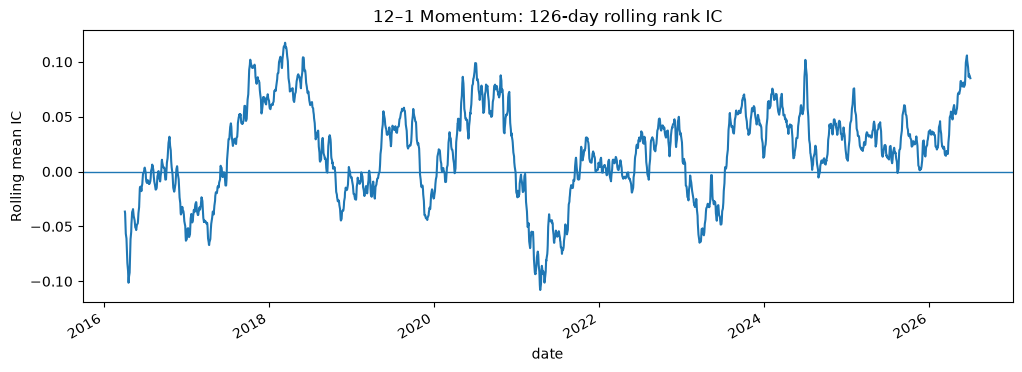

In [16]:
rank_ic = calculate_daily_ic(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    method="spearman",
    min_observations=30,
)

rolling_ic = calculate_rolling_ic(
    rank_ic,
    window=126,
    min_periods=63,
)

ax = rolling_ic.plot(
    x="date",
    y="rolling_ic_126",
    figsize=(12, 4),
    title="12–1 Momentum: 126-day rolling rank IC",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Rolling mean IC")

Text(0, 0.5, 'Rolling mean IC')

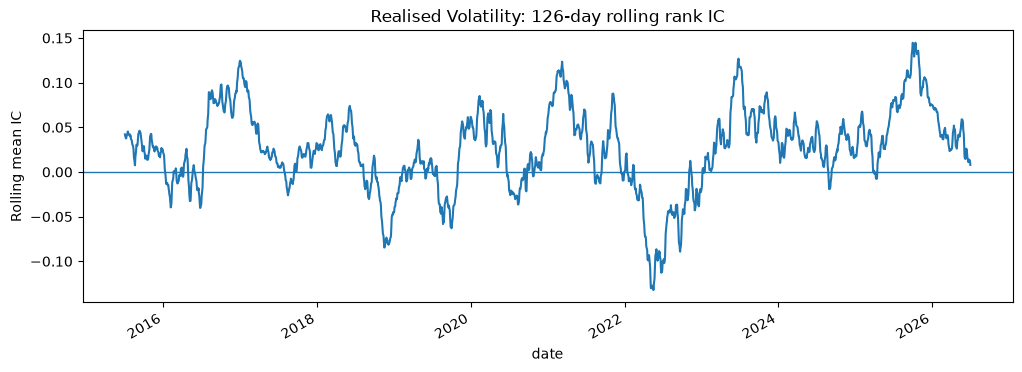

In [17]:
rank_ic = calculate_daily_ic(
    factor_panel,
    factor_column="realised_vol_63_z",
    forward_return_column="forward_ret_5d",
    method="spearman",
    min_observations=30,
)

rolling_ic = calculate_rolling_ic(
    rank_ic,
    window=126,
    min_periods=63,
)

ax = rolling_ic.plot(
    x="date",
    y="rolling_ic_126",
    figsize=(12, 4),
    title="Realised Volatility: 126-day rolling rank IC",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Rolling mean IC")

### Average quantile returns for each factor

In [18]:
quantile_summary_rows = []

for factor_name, factor_column in factor_columns.items():
    quantile_returns = calculate_quantile_returns(
        factor_panel,
        factor_column=factor_column,
        forward_return_column="forward_ret_5d",
        quantiles=5,
        min_observations=30,
    )

    averages = (
        quantile_returns
        .groupby("quantile")["mean_forward_return"]
        .mean()
    )

    row = {"factor": factor_name}

    for quantile, value in averages.items():
        row[f"Q{quantile}"] = value

    row["Q5_minus_Q1"] = averages.loc[5] - averages.loc[1]
    quantile_summary_rows.append(row)

quantile_summary = pd.DataFrame(quantile_summary_rows).set_index("factor")
quantile_summary

,Q1,Q2,Q3,Q4,Q5,Q5_minus_Q1
factor,,,,,,
12-1 Momentum,0.003978,0.003281,0.003234,0.003226,0.005296,0.001318
3-Month Momentum,0.004302,0.003284,0.002693,0.003074,0.004614,0.000312
1-Month Reversal,0.004050,0.003180,0.003178,0.003307,0.004268,0.000218
Realised Volatility,0.002306,0.002625,0.002818,0.003926,0.006290,0.003984
